# 04 Whisper 共享编码器情感分类训练

围绕毕设主线训练 Whisper 共享编码器情感模型，并统一支持三种训练模式：

- `live_encoder`：直接输入音频，训练 `Whisper Encoder -> Emotion Head`
- `cached_sequence`：预缓存序列特征 `(T, D)`，仅训练情感头
- `cached_pooled`：预缓存 pooled 特征，仅用于 `legacy_mlp` 兼容基线

模型结构、归一化、池化方式、冻结策略与 checkpoint 格式统一由 `configs/config.yaml` 中的 `shared_model` 配置控制。

In [1]:
import os
IN_COLAB = 'COLAB_GPU' in os.environ or 'COLAB_RELEASE_TAG' in os.environ

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_ROOT = '/content/drive/MyDrive/identifier'
    os.chdir(PROJECT_ROOT)
    !pip install -q openai-whisper noisereduce librosa soundfile pyyaml
else:
    # 自动查找项目根目录（兼容从任意目录启动 Jupyter）
    for _candidate in [os.path.abspath('..'), os.path.abspath('.'), os.path.expanduser('~/identifier')]:
        if os.path.isfile(os.path.join(_candidate, 'configs', 'config.yaml')):
            PROJECT_ROOT = _candidate
            break
    else:
        raise RuntimeError('找不到项目根目录，请确认 configs/config.yaml 存在')
    os.chdir(PROJECT_ROOT)

print(f'项目根目录: {os.getcwd()}')

项目根目录: /root/Emotion-perception-driven-speech-recognition-system


In [ ]:
import sys
import os
import time
import copy
import math
import random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
import whisper
import matplotlib.pyplot as plt

sys.path.insert(0, PROJECT_ROOT)
from utils.audio_utils import load_config, EMOTION_LABELS
from utils.losses import FocalLoss
from preprocessing.whisper_feature_cache import (
    prepare_whisper_training_data,
    build_whisper_mel_batch,
    collate_whisper_audio_batch,
    TRAINING_MODE_LIVE_ENCODER,
    TRAINING_MODE_CACHED_SEQUENCE,
    TRAINING_MODE_CACHED_POOLED,
)
from models.whisper_emotion import (
    WhisperEmotionHead,
    build_shared_model_from_config,
    create_shared_checkpoint,
    DEFAULT_SHARED_MODEL_CONFIG,
)

cfg = load_config()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'设备: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name()}')

seed = int(cfg['training'].get('seed', 42))
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

shared_cfg = dict(DEFAULT_SHARED_MODEL_CONFIG)
shared_cfg.update(cfg.get('shared_model', {}))
training_mode = str(shared_cfg.get('training_mode', TRAINING_MODE_LIVE_ENCODER)).strip().lower()
variant = str(shared_cfg.get('variant', 'transformer_head')).strip().lower()
whisper_size = cfg['model']['whisper_size']
num_classes = int(cfg['emotion']['num_classes'])

print('共享模型配置:')
print({
    'variant': variant,
    'training_mode': training_mode,
    'pooling': shared_cfg.get('pooling'),
    'norm': shared_cfg.get('norm'),
    'freeze_strategy': shared_cfg.get('freeze_strategy'),
    'head_layers': shared_cfg.get('head_layers'),
    'head_hidden_dim': shared_cfg.get('head_hidden_dim'),
    'num_heads': shared_cfg.get('num_heads'),
    'ff_mult': shared_cfg.get('ff_mult'),
})

## 1. 准备数据集

In [ ]:
feature_bs = int(cfg.get('training', {}).get('whisper_feature_batch_size', 8))
feature_workers = int(cfg.get('training', {}).get('whisper_feature_num_workers', 0))
feature_prefetch = int(cfg.get('training', {}).get('whisper_feature_prefetch_factor', 2))
cache_dtype = str(shared_cfg.get('cache_feature_dtype', 'float16'))
subsets = ('ravdess', 'casia', 'tess', 'esd', 'emodb', 'iemocap')

dataset, meta = prepare_whisper_training_data(
    cfg=cfg,
    device=device,
    subsets=subsets,
    batch_size=feature_bs,
    feature_dtype=cache_dtype,
    overwrite=False,
    num_workers=feature_workers,
    prefetch_factor=feature_prefetch,
)
print(f'训练数据元信息: {meta}')

total = len(dataset)
train_n = int(total * cfg['training']['train_ratio'])
val_n = int(total * cfg['training']['val_ratio'])
test_n = total - train_n - val_n

gen = torch.Generator().manual_seed(seed)
train_set, val_set, test_set = random_split(dataset, [train_n, val_n, test_n], generator=gen)

base_batch_size = int(cfg['training']['batch_size'])
default_live_train_batch_size = min(base_batch_size, 8)
default_live_eval_batch_size = min(default_live_train_batch_size, 4)
default_cached_sequence_batch_size = min(base_batch_size, 32)
default_cached_pooled_batch_size = base_batch_size

if training_mode == TRAINING_MODE_LIVE_ENCODER:
    train_batch_size = int(cfg['training'].get('live_encoder_batch_size', default_live_train_batch_size))
    eval_batch_size = int(cfg['training'].get('live_encoder_eval_batch_size', default_live_eval_batch_size))
elif training_mode == TRAINING_MODE_CACHED_SEQUENCE:
    train_batch_size = int(cfg['training'].get('cached_sequence_batch_size', default_cached_sequence_batch_size))
    eval_batch_size = int(cfg['training'].get('cached_sequence_eval_batch_size', train_batch_size))
else:
    train_batch_size = int(cfg['training'].get('cached_pooled_batch_size', default_cached_pooled_batch_size))
    eval_batch_size = int(cfg['training'].get('cached_pooled_eval_batch_size', train_batch_size))

pin_memory = device.type == 'cuda'

train_loader_kwargs = {
    'batch_size': train_batch_size,
    'pin_memory': pin_memory,
}
eval_loader_kwargs = {
    'batch_size': eval_batch_size,
    'pin_memory': pin_memory,
}
if training_mode == TRAINING_MODE_LIVE_ENCODER:
    train_loader_kwargs['collate_fn'] = collate_whisper_audio_batch
    eval_loader_kwargs['collate_fn'] = collate_whisper_audio_batch

train_loader = DataLoader(train_set, shuffle=True, **train_loader_kwargs)
val_loader = DataLoader(val_set, shuffle=False, **eval_loader_kwargs)
test_loader = DataLoader(test_set, shuffle=False, **eval_loader_kwargs)

print(
    f'训练: {train_n}, 验证: {val_n}, 测试: {test_n}, '
    f'train_batch_size: {train_batch_size}, eval_batch_size: {eval_batch_size}, '
    f'feature_num_workers: {feature_workers}, feature_prefetch_factor: {feature_prefetch}'
)

## 2. 构建模型

In [ ]:
active_variant = variant
effective_freeze_strategy = str(shared_cfg.get('freeze_strategy', 'freeze_all')).strip().lower()

if training_mode == TRAINING_MODE_CACHED_SEQUENCE and effective_freeze_strategy != 'freeze_all':
    print('注意: cached_sequence 无法更新 Whisper encoder，当前 notebook 将冻结策略改为 freeze_all。')
    effective_freeze_strategy = 'freeze_all'

if training_mode == TRAINING_MODE_CACHED_POOLED:
    effective_freeze_strategy = 'freeze_all'
    if active_variant != 'legacy_mlp':
        print('注意: cached_pooled 仅支持 legacy_mlp，当前 notebook 将自动切换到 legacy 基线。')
        active_variant = 'legacy_mlp'

shared_whisper_model = whisper.load_model(whisper_size, device=str(device))
if training_mode in (TRAINING_MODE_LIVE_ENCODER, TRAINING_MODE_CACHED_SEQUENCE):
    model = build_shared_model_from_config(
        shared_whisper_model,
        cfg,
        variant=active_variant,
        freeze_strategy=effective_freeze_strategy,
    ).to(device)
else:
    model = WhisperEmotionHead(
        shared_whisper_model,
        num_classes=num_classes,
        variant='legacy_mlp',
        freeze_strategy='freeze_all',
        pooling='mean',
        legacy_hidden_dims=shared_cfg.get('legacy_hidden_dims', (256, 64)),
        dropout=float(shared_cfg.get('dropout', 0.1)),
        whisper_size=whisper_size,
    ).to(device)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())
print(f'模型: {model.__class__.__name__}')
print(f'总参数: {total_params:,}')
print(f'可训练参数: {trainable:,}')
print({'variant': model.variant, **model.shared_config})

## 3. 训练

In [ ]:
def build_criterion(cfg, device):
    label_smoothing = float(cfg['training'].get('label_smoothing', 0.0))
    if bool(cfg['training'].get('focal_loss', False)):
        return FocalLoss(
            gamma=float(cfg['training'].get('focal_gamma', 2.0)),
            label_smoothing=label_smoothing,
        ).to(device)
    return nn.CrossEntropyLoss(label_smoothing=label_smoothing).to(device)


def move_batch_to_device(batch, device, training_mode):
    if training_mode == TRAINING_MODE_LIVE_ENCODER:
        audios, srs, labels = batch
        labels = labels.to(device, non_blocking=True)
        mel_batch, attention_mask = build_whisper_mel_batch(audios, srs, device)
        return {
            'mel': mel_batch,
            'attention_mask': attention_mask,
            'labels': labels,
        }
    if training_mode == TRAINING_MODE_CACHED_SEQUENCE:
        sequence_features, labels, attention_mask = batch
        return {
            'sequence_features': sequence_features.to(device, non_blocking=True),
            'attention_mask': attention_mask.to(device, non_blocking=True),
            'labels': labels.to(device, non_blocking=True),
        }
    feats, labels = batch
    return {
        'sequence_features': feats.to(device, non_blocking=True),
        'labels': labels.to(device, non_blocking=True),
    }


def forward_model(model, batch_inputs, training_mode):
    if training_mode == TRAINING_MODE_LIVE_ENCODER:
        return model(
            mel=batch_inputs['mel'],
            attention_mask=batch_inputs['attention_mask'],
        )
    if training_mode == TRAINING_MODE_CACHED_SEQUENCE:
        return model(
            sequence_features=batch_inputs['sequence_features'],
            attention_mask=batch_inputs['attention_mask'],
        )
    return model(sequence_features=batch_inputs['sequence_features'])


def run_epoch(model, loader, criterion, optimizer, training_mode, device, train=True, scaler=None, grad_accum_steps=1):
    model.train(train)
    total_loss = 0.0
    total_correct = 0
    total_count = 0
    use_amp = device.type == 'cuda' and training_mode == TRAINING_MODE_LIVE_ENCODER

    if train:
        optimizer.zero_grad(set_to_none=True)

    grad_ctx = torch.enable_grad() if train else torch.no_grad()
    with grad_ctx:
        for step, batch in enumerate(loader, start=1):
            batch_inputs = move_batch_to_device(batch, device, training_mode)
            labels = batch_inputs['labels']

            with torch.autocast(device_type='cuda', dtype=torch.float16, enabled=use_amp):
                logits = forward_model(model, batch_inputs, training_mode)
                loss = criterion(logits, labels)

            batch_size = int(labels.size(0))
            total_loss += loss.item() * batch_size
            total_correct += (logits.argmax(dim=1) == labels).sum().item()
            total_count += batch_size

            if train:
                loss_for_backward = loss / grad_accum_steps
                if scaler is not None and use_amp:
                    scaler.scale(loss_for_backward).backward()
                else:
                    loss_for_backward.backward()

                should_step = (step % grad_accum_steps == 0) or (step == len(loader))
                if should_step:
                    if scaler is not None and use_amp:
                        scaler.step(optimizer)
                        scaler.update()
                    else:
                        optimizer.step()
                    optimizer.zero_grad(set_to_none=True)

            del batch_inputs, labels, logits, loss
            if device.type == 'cuda' and not train:
                torch.cuda.empty_cache()

    return total_loss / total_count, total_correct / total_count


criterion = build_criterion(cfg, device)
optimizer = torch.optim.AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=cfg['training']['learning_rate'],
    weight_decay=cfg['training']['weight_decay'],
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=5, factor=0.5,
)

epochs = int(cfg['training']['epochs'])
patience = int(cfg['training']['patience'])
grad_accum_steps = int(cfg['training'].get('grad_accum_steps', 1 if training_mode != TRAINING_MODE_LIVE_ENCODER else max(1, math.ceil(base_batch_size / train_batch_size))))
scaler = torch.amp.GradScaler('cuda', enabled=(device.type == 'cuda' and training_mode == TRAINING_MODE_LIVE_ENCODER))
best_val_loss = float('inf')
best_state = None
wait = 0
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

print({
    'grad_accum_steps': grad_accum_steps,
    'amp_enabled': bool(device.type == 'cuda' and training_mode == TRAINING_MODE_LIVE_ENCODER),
})

for epoch in range(1, epochs + 1):
    t0 = time.time()

    tr_loss, tr_acc = run_epoch(
        model, train_loader, criterion, optimizer,
        training_mode=training_mode, device=device, train=True,
        scaler=scaler, grad_accum_steps=grad_accum_steps,
    )
    vl_loss, vl_acc = run_epoch(
        model, val_loader, criterion, optimizer=None,
        training_mode=training_mode, device=device, train=False,
        scaler=None, grad_accum_steps=1,
    )

    scheduler.step(vl_loss)
    elapsed = time.time() - t0

    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)
    history['val_loss'].append(vl_loss)
    history['val_acc'].append(vl_acc)

    print(
        f'Epoch {epoch:3d}/{epochs} | '
        f'Train Loss: {tr_loss:.4f} Acc: {tr_acc:.4f} | '
        f'Val Loss: {vl_loss:.4f} Acc: {vl_acc:.4f} | {elapsed:.1f}s'
    )

    if vl_loss < best_val_loss:
        best_val_loss = vl_loss
        best_state = copy.deepcopy(model.state_dict())
        wait = 0
        print('  -> 最佳模型已保存')
    else:
        wait += 1
        if wait >= patience:
            print(f'\n早停: 连续 {patience} 轮无改善')
            break

os.makedirs(cfg['paths']['checkpoints'], exist_ok=True)
model.load_state_dict(best_state)
checkpoint = create_shared_checkpoint(
    model,
    cfg,
    extra={
        'training_mode': training_mode,
        'data_meta': meta,
        'best_val_loss': float(best_val_loss),
        'grad_accum_steps': int(grad_accum_steps),
        'train_batch_size': int(train_batch_size),
        'eval_batch_size': int(eval_batch_size),
        'amp_enabled': bool(device.type == 'cuda' and training_mode == TRAINING_MODE_LIVE_ENCODER),
    },
)
torch.save(checkpoint, cfg['paths']['best_shared_model'])
np.savez(os.path.join(cfg['paths']['checkpoints'], 'shared_history.npz'), **history)
print(f"模型已保存至: {cfg['paths']['best_shared_model']}")

## 4. 训练曲线

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(history['train_loss'], label='Train')
ax1.plot(history['val_loss'], label='Validation')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title(f'Loss - Whisper Shared ({training_mode})')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(history['train_acc'], label='Train')
ax2.plot(history['val_acc'], label='Validation')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
ax2.set_title(f'Accuracy - Whisper Shared ({training_mode})')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(cfg['paths']['checkpoints'], 'shared_training_curves.png'), dpi=150)
plt.show()

## 5. 测试集评估

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

model.eval()

all_preds, all_labels_list = [], []
with torch.no_grad():
    for batch in test_loader:
        batch_inputs = move_batch_to_device(batch, device, training_mode)
        logits = forward_model(model, batch_inputs, training_mode)
        preds = logits.argmax(dim=1).cpu().numpy()
        labels = batch_inputs['labels'].cpu().numpy()
        all_preds.extend(preds)
        all_labels_list.extend(labels)

label_ids = list(range(len(EMOTION_LABELS)))
print(
    classification_report(
        all_labels_list,
        all_preds,
        labels=label_ids,
        target_names=EMOTION_LABELS,
        zero_division=0,
    )
)

cm = confusion_matrix(all_labels_list, all_preds, labels=label_ids)
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(cm, display_labels=EMOTION_LABELS).plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title(f'Confusion Matrix - Whisper Shared ({training_mode})')
plt.tight_layout()
plt.savefig(os.path.join(cfg['paths']['checkpoints'], 'shared_confusion_matrix.png'), dpi=150)
plt.show()

## 6. 对比两个模型
如果之前已经训练过 CNN+BiLSTM+Attention 模型，可以加载对比。

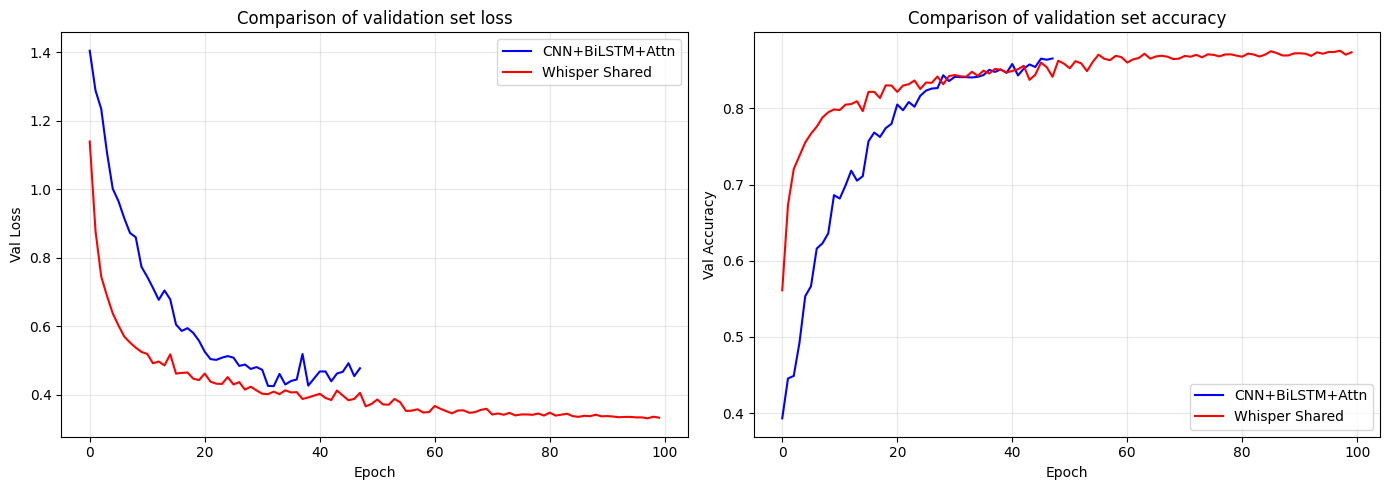

In [8]:
emotion_hist_path = os.path.join(cfg['paths']['checkpoints'], 'emotion_history.npz')
shared_hist_path = os.path.join(cfg['paths']['checkpoints'], 'shared_history.npz')

if os.path.isfile(emotion_hist_path) and os.path.isfile(shared_hist_path):
    eh = np.load(emotion_hist_path)
    sh = np.load(shared_hist_path)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.plot(eh['val_loss'], label='CNN+BiLSTM+Attn', color='blue')
    ax1.plot(sh['val_loss'], label='Whisper Shared', color='red')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Val Loss')
    ax1.set_title('Comparison of validation set loss')
    ax1.legend(); ax1.grid(True, alpha=0.3)
    
    ax2.plot(eh['val_acc'], label='CNN+BiLSTM+Attn', color='blue')
    ax2.plot(sh['val_acc'], label='Whisper Shared', color='red')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Val Accuracy')
    ax2.set_title('Comparison of validation set accuracy')
    ax2.legend(); ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(cfg['paths']['checkpoints'], 'model_comparison.png'), dpi=150)
    plt.show()
else:
    print('缺少其中一个模型的训练历史，跳过对比。')